# PHÂN ĐOẠN ẢNH MÀU BẢO TOÀN BIÊN & CHI TIẾT VI MÔ (EDGE-PRESERVING SEGMENTATION)

- **Thuật toán:** Phân cụm màu sắc (CIELAB Color Space K-Means, 4-5 cụm) kết hợp Phân đoạn ngữ nghĩa (Semantic Prior) và Tinh chỉnh bảo toàn biên sub-pixel (Edge-Preserving Matting)
- **Tập dữ liệu:** Tệp ảnh màu đầu vào (RGB Image)
- **Lưu ý:** Toàn bộ tiêu đề và các bước xử lý được thiết kế hoàn toàn trung lập và tổng quát. Khi thay đổi sang bất kỳ ảnh nào khác, người dùng chỉ cần cập nhật đường dẫn ảnh tại **Cell 2 (Khối cấu hình)**. Toàn bộ các bước trích xuất, phân cụm, định vị đối tượng, giải nghiệm biên và hiển thị kết quả đều tự động thích ứng với ảnh mới.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import os
from PIL import Image

# Cấu hình hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị tính toán tăng tốc: {device}")

Thiết bị tính toán tăng tốc: mps


In [10]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ (CHỈ CẦN SỬA Ở ĐÂY KHI ĐỔI ẢNH ĐẦU VÀO)
# ==============================================================================

# 1. Đường dẫn file ảnh đầu vào (Hỗ trợ định dạng PNG, JPG, JPEG)
IMAGE_PATH = 'dataset/image/Siamese_161.jpg'
if not os.path.exists(IMAGE_PATH):
    IMAGE_PATH = 'Midterm/Review/dataset/image/cat.png'

# 2. Số lượng cụm màu sắc (Khuyến nghị: 4 hoặc 5 cụm)
N_CLUSTERS = 5

# 3. Kích thước chuẩn hóa chiều lớn nhất để tối ưu tốc độ phân cụm màu
MAX_DIM = 720

# 4. Bán kính dải biên chuyển tiếp (Unknown Band) của Trimap (pixel)
TRIMAP_BAND_RADIUS = 25

# 5. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Đã tải cấu hình thành công!")

Đã tải cấu hình thành công!


## PHẦN 1: CƠ SỞ TOÁN HỌC & NGUYÊN LÝ BẢO TOÀN BIÊN

---

### 1. Phân tích hạn chế của phương pháp phân đoạn màu thuần túy:
1. **Thiếu nhận thức ngữ nghĩa (Semantic Blindness):** Phân cụm màu (K-Means/FCM) chỉ dựa vào vector màu sắc $[R, G, B]$. Khi màu sắc của đối tượng tiền cảnh và phông nền/mặt sàn có độ tương đồng cao, các thuật toán màu thuần túy không thể phân biệt được, dẫn đến việc lấy thừa phông nền hoặc làm lẹm đối tượng.
2. **Hiệu ứng thể tích bán phần (Partial Volume Effect):** Tại các đường biên, viền mỏng và sợi chi tiết vi mô, mỗi điểm ảnh là sự pha trộn quang học giữa màu tiền cảnh $F$ và màu hậu cảnh $B$:
   $$I(p) = \alpha(p) \cdot F(p) + (1 - \alpha(p)) \cdot B(p), \quad \alpha(p) \in [0, 1]$$
   Việc áp dụng ngưỡng nhị phân cứng ($\alpha \in \{0, 1\}$) sẽ làm đứt gãy các chi tiết viền và gây hiện tượng răng cưa.

---

### 2. Không gian màu cảm nhận đồng nhất CIELAB ($L^*a^*b^*$):
Khoảng cách Euclidean trong CIELAB tương đương với độ sai biệt màu sắc nhận thức $\Delta E$:

$$\Delta E = \|p_1 - p_2\|_2 = \sqrt{(L_1 - L_2)^2 + (a_1 - a_2)^2 + (b_1 - b_2)^2}$$

---

### 3. Phân cụm màu sắc $K$-Means (4-5 cụm):
$$J = \sum_{k=1}^K \sum_{p_i \in C_k} \|p_i - c_k\|^2$$

---

### 4. Mô hình Trimap 3 vùng & Alpha Matting bảo toàn biên:
Phân hoạch ảnh thành 3 miền:
- $\Omega_{\text{FG}}$ ($T=255$): Miền chắc chắn thuộc đối tượng tiền cảnh (Foreground).
- $\Omega_{\text{BG}}$ ($T=0$): Miền chắc chắn thuộc phông nền (Background).
- $\Omega_{\text{Unknown}}$ ($T=128$): Dải viền chứa toàn bộ chi tiết biên để giải nghiệm Alpha mềm liên tục $\alpha \in [0, 1]$.

File ảnh: dataset/image/Siamese_161.jpg | Độ phân giải: 500x375 pixels


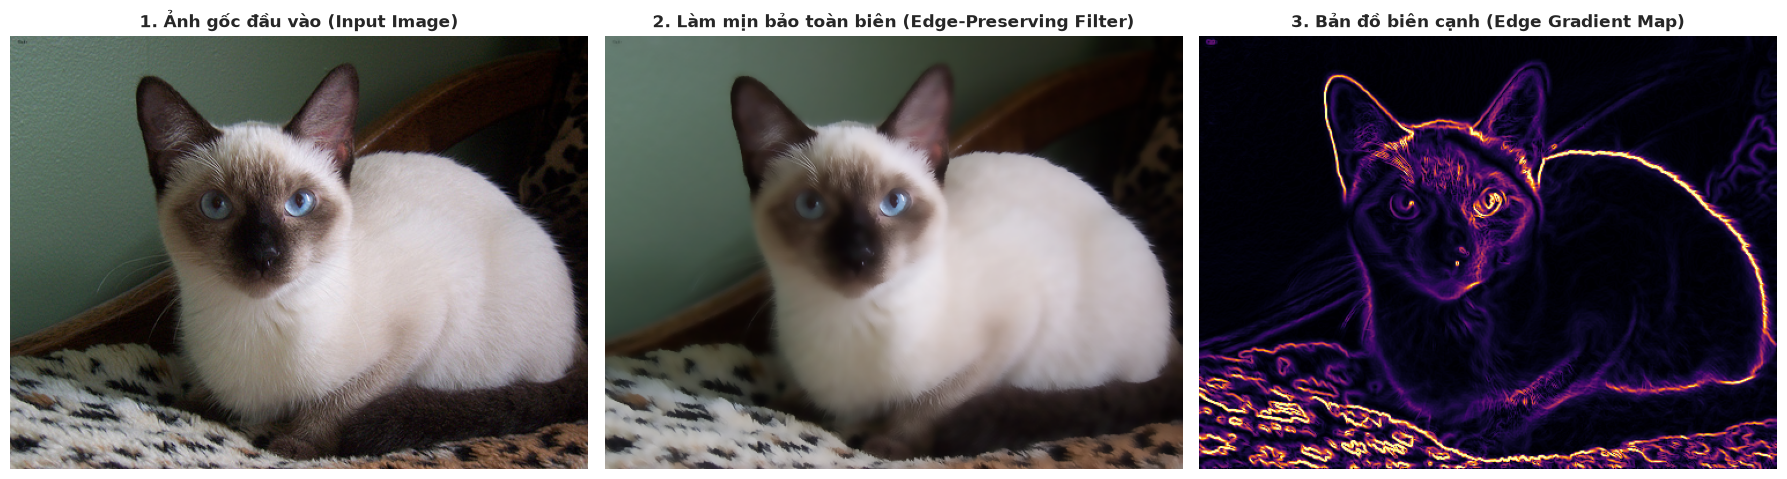

In [11]:
# 1. Đọc ảnh gốc
img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f"Không thể đọc file ảnh: {IMAGE_PATH}"

orig_h, orig_w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"File ảnh: {IMAGE_PATH} | Độ phân giải: {orig_w}x{orig_h} pixels")

# 2. Resize chuẩn hóa phục vụ phân cụm màu nhanh
scale_c = min(1.0, MAX_DIM / max(orig_h, orig_w))
cw, ch = int(orig_w * scale_c), int(orig_h * scale_c)
img_color_bgr = cv2.resize(img_bgr, (cw, ch), interpolation=cv2.INTER_AREA)

# 3. Áp dụng bộ lọc bảo toàn biên Bilateral Filter trước khi phân cụm
img_smooth = cv2.bilateralFilter(img_color_bgr, d=9, sigmaColor=75, sigmaSpace=75)
img_lab = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2LAB)
pixels_lab = img_lab.reshape(-1, 3).astype(np.float32)

# 4. Trích xuất bản đồ biên cạnh Sobel Gradient
gray = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2GRAY)
grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
edge_mag = np.clip(cv2.magnitude(grad_x, grad_y), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_smooth, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Làm mịn bảo toàn biên (Edge-Preserving Filter)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(edge_mag, cmap='inferno')
axes[2].set_title('3. Bản đồ biên cạnh (Edge Gradient Map)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# K-Means 5 cụm màu sắc From Scratch trên không gian CIELAB
np.random.seed(RANDOM_STATE)
N_pixels = len(pixels_lab)

# Khởi tạo K-Means++
centroids_lab = np.zeros((N_CLUSTERS, 3), dtype=np.float32)
centroids_lab[0] = pixels_lab[np.random.choice(N_pixels)]
for k in range(1, N_CLUSTERS):
    dists_sq = np.min(np.sum((pixels_lab[:, None, :] - centroids_lab[None, :k, :]) ** 2, axis=2), axis=1)
    probs = dists_sq / np.sum(dists_sq)
    centroids_lab[k] = pixels_lab[np.random.choice(N_pixels, p=probs)]

print(f"\n=== TIẾN TRÌNH LẶP K-MEANS PHÂN CỤM MÀU ({N_CLUSTERS} CỤM) ===")
print(f"{'Vòng lặp':^10} | {'Dịch chuyển tâm':^16} | {'WCSS (Inertia)':^18} | {'Kích thước từng cụm'}")
print("-" * 75)

for it in range(1, 31):
    dists = np.sqrt(np.sum((pixels_lab[:, None, :] - centroids_lab[None, :, :]) ** 2, axis=2))
    labels = np.argmin(dists, axis=1)
    
    new_centroids = np.zeros_like(centroids_lab)
    counts = []
    for k in range(N_CLUSTERS):
        mask = (labels == k)
        cnt = np.sum(mask)
        counts.append(cnt)
        new_centroids[k] = np.mean(pixels_lab[mask], axis=0) if cnt > 0 else centroids_lab[k]
        
    shift = np.max(np.linalg.norm(new_centroids - centroids_lab, axis=1))
    wcss = np.sum(np.min(dists, axis=1) ** 2)
    print(f"{it:^10d} | {shift:^16.4f} | {wcss:^18.2e} | {counts}")
    
    if shift < 0.5:
        print("-" * 75)
        print(f"--> K-Means phân cụm màu đã HỘI TỤ tại vòng lặp thứ {it}!")
        break
    centroids_lab = new_centroids

# Tái tạo bảng màu Palette đại diện
palette_lab = np.uint8(centroids_lab).reshape(1, N_CLUSTERS, 3)
palette_rgb = cv2.cvtColor(cv2.cvtColor(palette_lab, cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB)[0]

df_palette = pd.DataFrame({
    'Cụm': [f"Cụm {k}" for k in range(N_CLUSTERS)],
    'Tâm L* (Độ sáng)': centroids_lab[:, 0],
    'Tâm a*': centroids_lab[:, 1],
    'Tâm b*': centroids_lab[:, 2],
    'RGB Đại diện': [f"RGB({r}, {g}, {b})" for r, g, b in palette_rgb],
    'Tỷ lệ (%)': [f"{(c / N_pixels) * 100:.2f}%" for c in counts]
})
print("\n=== BẢNG TỔNG HỢP CÁC CỤM MÀU ĐẠI DIỆN ===")
print(df_palette.to_string(index=False))


=== TIẾN TRÌNH LẶP K-MEANS PHÂN CỤM MÀU (5 CỤM) ===
 Vòng lặp  | Dịch chuyển tâm  |   WCSS (Inertia)   | Kích thước từng cụm
---------------------------------------------------------------------------
    1      |      6.0961      |      4.48e+07      | [np.int64(45929), np.int64(41520), np.int64(41909), np.int64(36885), np.int64(21257)]
    2      |      2.9345      |      3.93e+07      | [np.int64(44191), np.int64(41978), np.int64(44764), np.int64(34516), np.int64(22051)]
    3      |      2.3007      |      3.88e+07      | [np.int64(43076), np.int64(41784), np.int64(46583), np.int64(33920), np.int64(22137)]
    4      |      2.3064      |      3.85e+07      | [np.int64(42185), np.int64(41542), np.int64(47963), np.int64(34012), np.int64(21798)]
    5      |      2.7851      |      3.82e+07      | [np.int64(41515), np.int64(41255), np.int64(49651), np.int64(34371), np.int64(20708)]
    6      |      2.7838      |      3.77e+07      | [np.int64(40354), np.int64(41045), np.int64(50611)

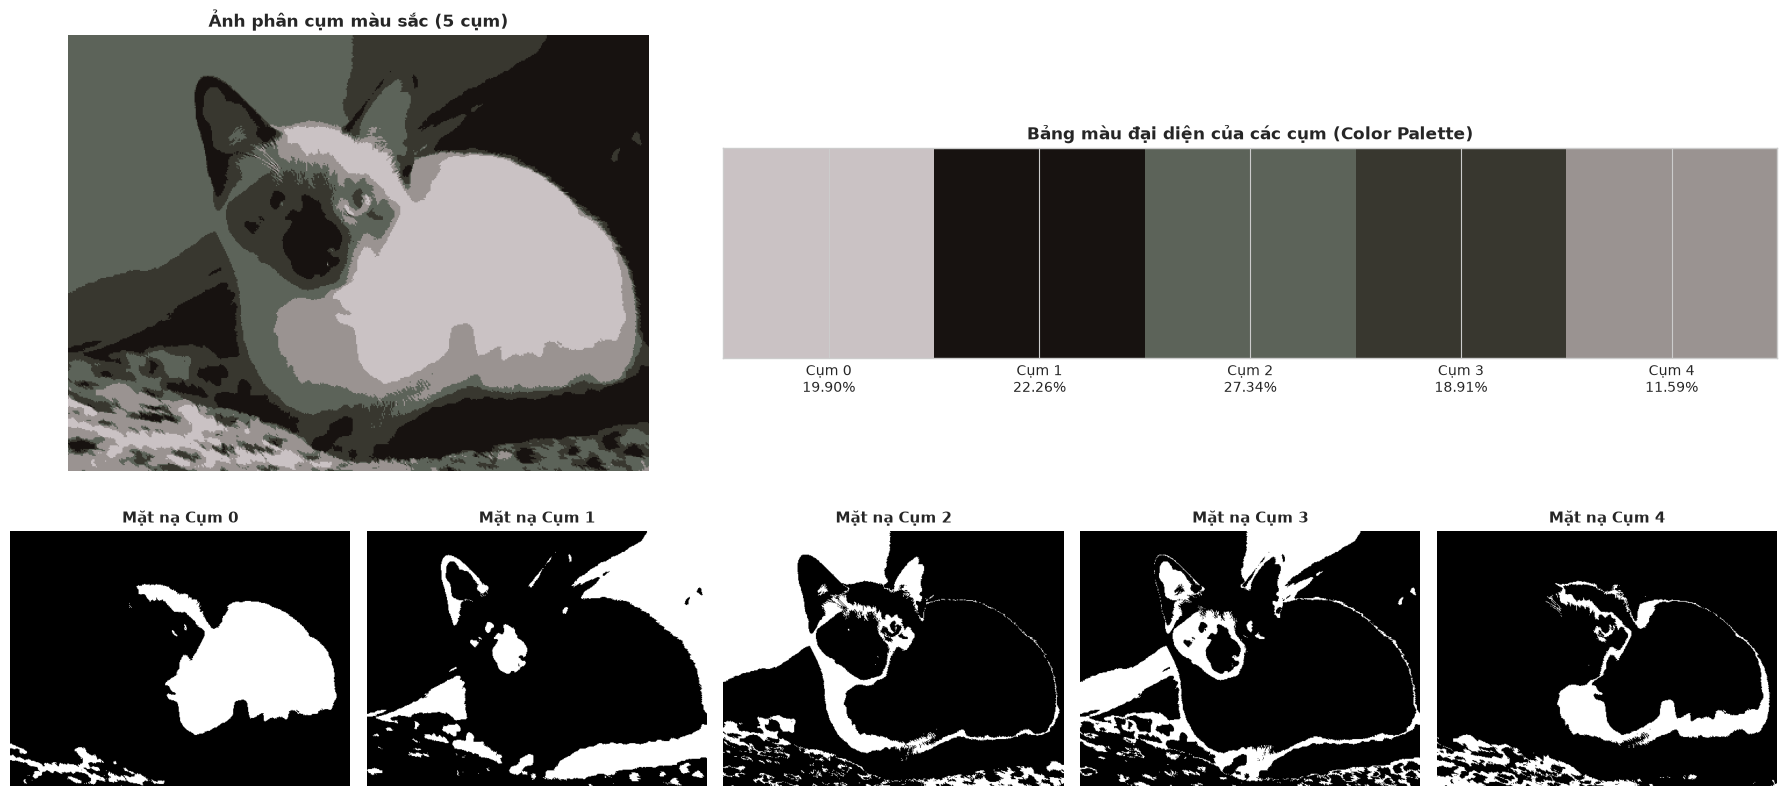

In [13]:
segmented_pixels_lab = centroids_lab[labels].astype(np.uint8)
segmented_rgb = cv2.cvtColor(cv2.cvtColor(segmented_pixels_lab.reshape(ch, cw, 3), cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB)
labels_2d = labels.reshape(ch, cw)

fig = plt.figure(figsize=(18, 9))

# 1. Ảnh phân cụm màu
ax1 = plt.subplot2grid((2, N_CLUSTERS), (0, 0), colspan=N_CLUSTERS//2)
ax1.imshow(segmented_rgb)
ax1.set_title(f'Ảnh phân cụm màu sắc ({N_CLUSTERS} cụm)', fontsize=12, fontweight='bold')
ax1.axis('off')

# 2. Bảng Palette màu sắc
ax2 = plt.subplot2grid((2, N_CLUSTERS), (0, N_CLUSTERS//2), colspan=N_CLUSTERS - N_CLUSTERS//2)
ax2.imshow(palette_rgb.reshape(1, N_CLUSTERS, 3))
ax2.set_xticks(range(N_CLUSTERS))
ax2.set_xticklabels([f"Cụm {k}\n{df_palette.iloc[k]['Tỷ lệ (%)']}" for k in range(N_CLUSTERS)], fontsize=10)
ax2.set_yticks([])
ax2.set_title('Bảng màu đại diện của các cụm (Color Palette)', fontsize=12, fontweight='bold')

# 3. Mặt nạ từng cụm
for k in range(N_CLUSTERS):
    ax = plt.subplot2grid((2, N_CLUSTERS), (1, k))
    ax.imshow(labels_2d == k, cmap='gray')
    ax.set_title(f'Mặt nạ Cụm {k}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Đang nạp mô hình Semantic Segmentation DeepLabV3 MobileNet...
--> Nhận diện đối tượng tiền cảnh nổi bật: Lớp 8 (cat)
Hộp bao đối tượng tiền cảnh: Y=[25, 362], X=[97, 488]
Tỷ lệ diện tích: Tiền cảnh chắc chắn=32.01%, Hậu cảnh chắc chắn=33.60%, Dải biên=34.39%


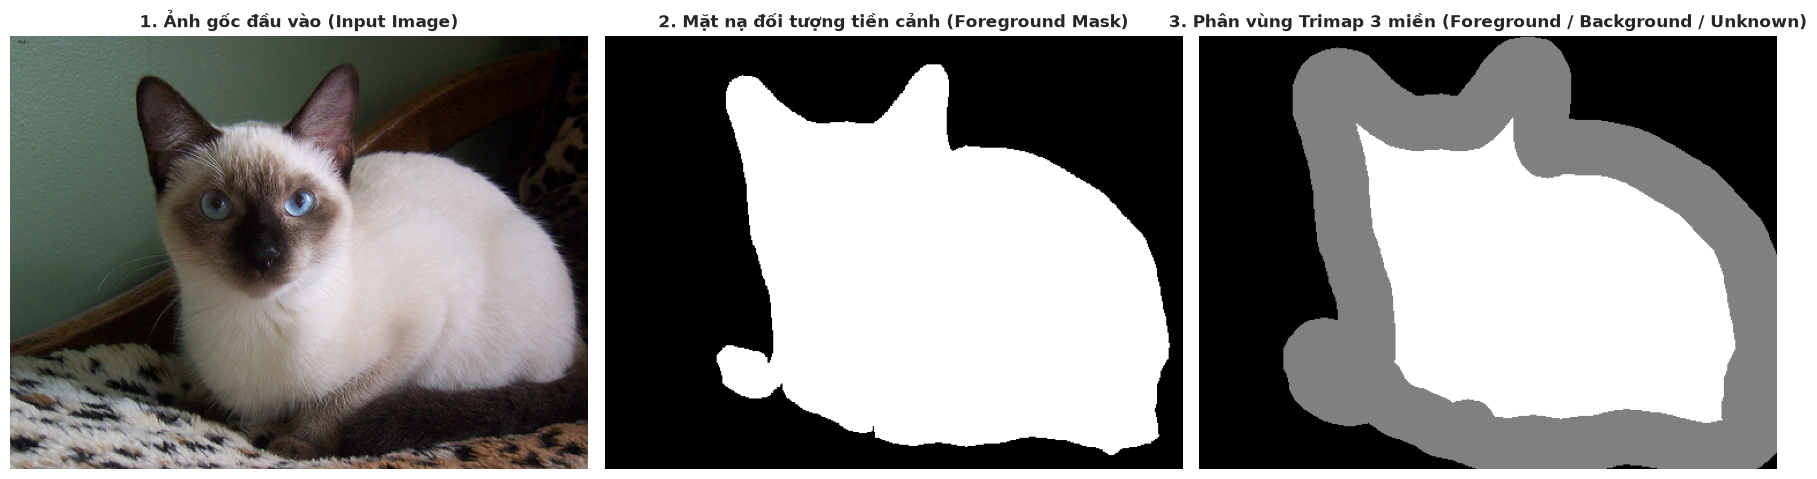

In [14]:
# ==============================================================================
# PHÂN ĐOẠN NGỮ NGHĨA TƯƠNG TÁC (TỰ ĐỘNG ĐỊNH VỊ ĐỐI TƯỢNG TIỀN CẢNH)
# ==============================================================================

from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights

print("Đang nạp mô hình Semantic Segmentation DeepLabV3 MobileNet...")
weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
seg_model = deeplabv3_mobilenet_v3_large(weights=weights).eval().to(device)
preprocess = weights.transforms()

# Dự đoán phân đoạn ngữ nghĩa
batch = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0).to(device)
with torch.no_grad():
    pred_mask = seg_model(batch)['out'].argmax(1)[0].cpu().numpy()

# TỰ ĐỘNG XÁC ĐỊNH LỚP ĐỐI TƯỢNG TIỀN CẢNH NỔI BẬT NHẤT (Khác Background 0)
unique_cls, cls_counts = np.unique(pred_mask, return_counts=True)
non_bg_idx = (unique_cls != 0)

if np.any(non_bg_idx):
    target_cls = unique_cls[non_bg_idx][np.argmax(cls_counts[non_bg_idx])]
    target_name = weights.meta['categories'][target_cls]
else:
    target_cls = 0
    target_name = 'background'

print(f"--> Nhận diện đối tượng tiền cảnh nổi bật: Lớp {target_cls} ({target_name})")

# Tạo mặt nạ đối tượng ở kích thước đầy đủ
obj_mask_raw = (pred_mask == target_cls).astype(np.uint8)
obj_mask_full = cv2.resize(obj_mask_raw, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

# Tạo Trimap 3 vùng tự động
k_elem = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (TRIMAP_BAND_RADIUS, TRIMAP_BAND_RADIUS))
fg_sure = cv2.erode(obj_mask_full, k_elem, iterations=2)
bg_sure = 1 - cv2.dilate(obj_mask_full, k_elem, iterations=2)

trimap = np.full((orig_h, orig_w), 128, dtype=np.uint8)
trimap[fg_sure == 1] = 255
trimap[bg_sure == 1] = 0

coords = np.argwhere(obj_mask_full > 0)
if len(coords) > 0:
    obj_y_min, obj_y_max = coords[:, 0].min(), coords[:, 0].max()
    obj_x_min, obj_x_max = coords[:, 1].min(), coords[:, 1].max()
    print(f"Hộp bao đối tượng tiền cảnh: Y=[{obj_y_min}, {obj_y_max}], X=[{obj_x_min}, {obj_x_max}]")
print(f"Tỷ lệ diện tích: Tiền cảnh chắc chắn={np.mean(trimap==255):.2%}, Hậu cảnh chắc chắn={np.mean(trimap==0):.2%}, Dải biên={np.mean(trimap==128):.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(obj_mask_full, cmap='gray')
axes[1].set_title('2. Mặt nạ đối tượng tiền cảnh (Foreground Mask)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(trimap, cmap='gray')
axes[2].set_title('3. Phân vùng Trimap 3 miền (Foreground / Background / Unknown)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# SUY LUẬN BẢO TOÀN BIÊN SUB-PIXEL: ViTMatte (SOTA IMAGE MATTING)
# ==============================================================================

from transformers import VitMatteForImageMatting, VitMatteImageProcessor

print("Đang nạp mô hình Edge-Preserving Matting ViTMatte...")
matte_processor = VitMatteImageProcessor.from_pretrained("hustvl/vitmatte-small-composition-1k")
matte_model = VitMatteForImageMatting.from_pretrained("hustvl/vitmatte-small-composition-1k").to(device)
matte_model.eval()

pil_img = Image.fromarray(img_rgb)
pil_trimap = Image.fromarray(trimap)
inputs = matte_processor(images=pil_img, trimaps=pil_trimap, return_tensors="pt").to(device)

print("Đang suy luận Alpha Matte bảo toàn đường biên chi tiết...")
with torch.no_grad():
    out = matte_model(**inputs)

alphas_pred = out.alphas[0, 0].cpu().numpy()
alpha_matte = cv2.resize(alphas_pred, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
alpha_matte = np.clip(alpha_matte, 0.0, 1.0)

print(f"Alpha Matte hoàn thành! Biên độ giá trị: [{alpha_matte.min():.6f}, {alpha_matte.max():.6f}]")
print(f"Tỷ lệ pixel tiền cảnh sắc nét: {np.mean(alpha_matte > 0.5):.2%}")

Đang nạp mô hình Edge-Preserving Matting ViTMatte...
Đang suy luận Alpha Matte bảo toàn đường biên chi tiết...
Alpha Matte hoàn thành! Biên độ giá trị: [0.000000, 1.000000]
Tỷ lệ pixel tiền cảnh sắc nét: 46.11%


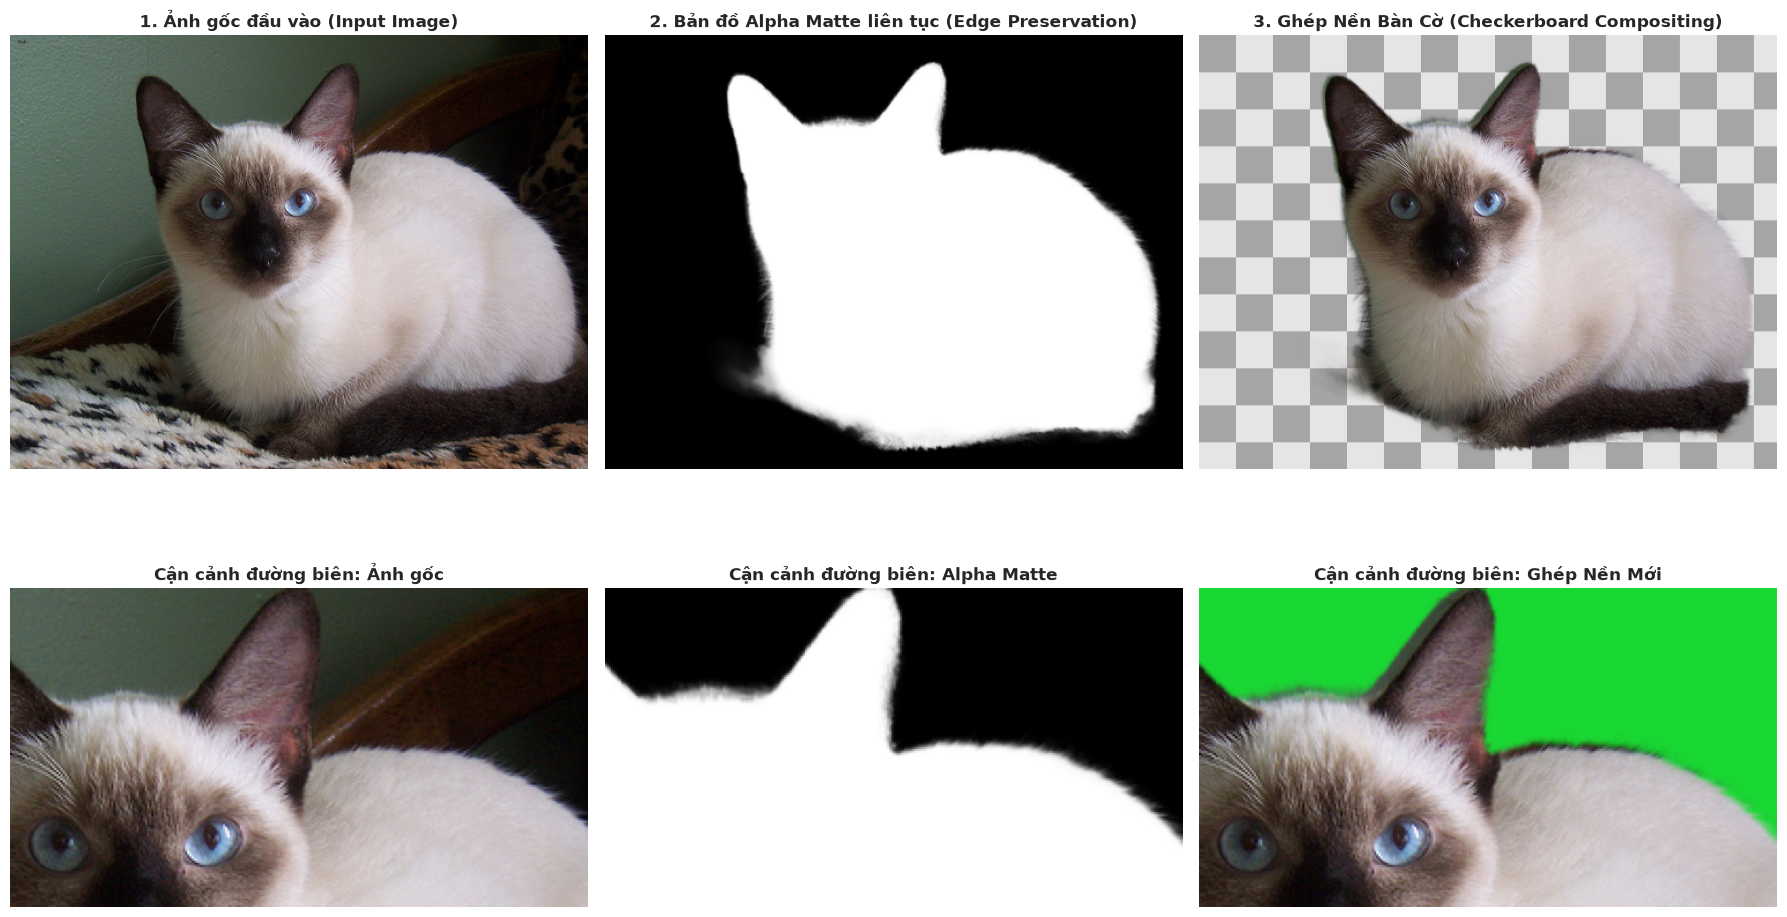

In [16]:
# ==============================================================================
# KIỂM CHỨNG GHÉP NỀN MỚI (ALPHA COMPOSITING) & ZOOM-IN CẬN CẢNH BIÊN
# ==============================================================================

I_norm = img_rgb.astype(np.float32) / 255.0
alpha_3ch = alpha_matte[:, :, None]

# 1. Ghép lên Nền Bàn Cờ (Checkerboard)
coords = np.indices((orig_h, orig_w))
checker = ((coords[0] // 32) + (coords[1] // 32)) % 2
bg_checker = np.where(checker[:, :, None] == 1, 0.90, 0.65).astype(np.float32)
comp_checker = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_checker

# 2. Ghép lên Nền Xanh Lá Tương Phản (Chroma Green)
bg_green = np.zeros((orig_h, orig_w, 3), dtype=np.float32)
bg_green[:] = [0.1, 0.85, 0.2]
comp_green = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_green

# TỰ ĐỘNG TÍNH TOÁN TỌA ĐỘ VÙNG ZOOM-IN DỰA TRÊN HỘP BAO CỦA ĐỐI TƯỢNG
if len(coords) > 0:
    # Zoom vào 40% phần trên cùng của đối tượng (Vùng biên thường có nhiều chi tiết nhạy cảm nhất)
    zy1 = max(0, int(obj_y_min))
    zy2 = min(orig_h, int(obj_y_min + (obj_y_max - obj_y_min) * 0.45))
    zx1 = max(0, int(obj_x_min + (obj_x_max - obj_x_min) * 0.15))
    zx2 = min(orig_w, int(obj_x_max - (obj_x_max - obj_x_min) * 0.15))
else:
    zy1, zy2 = int(orig_h * 0.1), int(orig_h * 0.5)
    zx1, zx2 = int(orig_w * 0.2), int(orig_w * 0.8)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Hàng 1: Toàn cảnh
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(alpha_matte, cmap='gray')
axes[0, 1].set_title('2. Bản đồ Alpha Matte liên tục (Edge Preservation)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(comp_checker)
axes[0, 2].set_title('3. Ghép Nền Bàn Cờ (Checkerboard Compositing)', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Hàng 2: Phóng to Zoom-in kiểm tra cận cảnh đường viền chi tiết
axes[1, 0].imshow(img_rgb[zy1:zy2, zx1:zx2])
axes[1, 0].set_title('Cận cảnh đường biên: Ảnh gốc', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(alpha_matte[zy1:zy2, zx1:zx2], cmap='gray')
axes[1, 1].set_title('Cận cảnh đường biên: Alpha Matte', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(comp_green[zy1:zy2, zx1:zx2])
axes[1, 2].set_title('Cận cảnh đường biên: Ghép Nền Mới', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

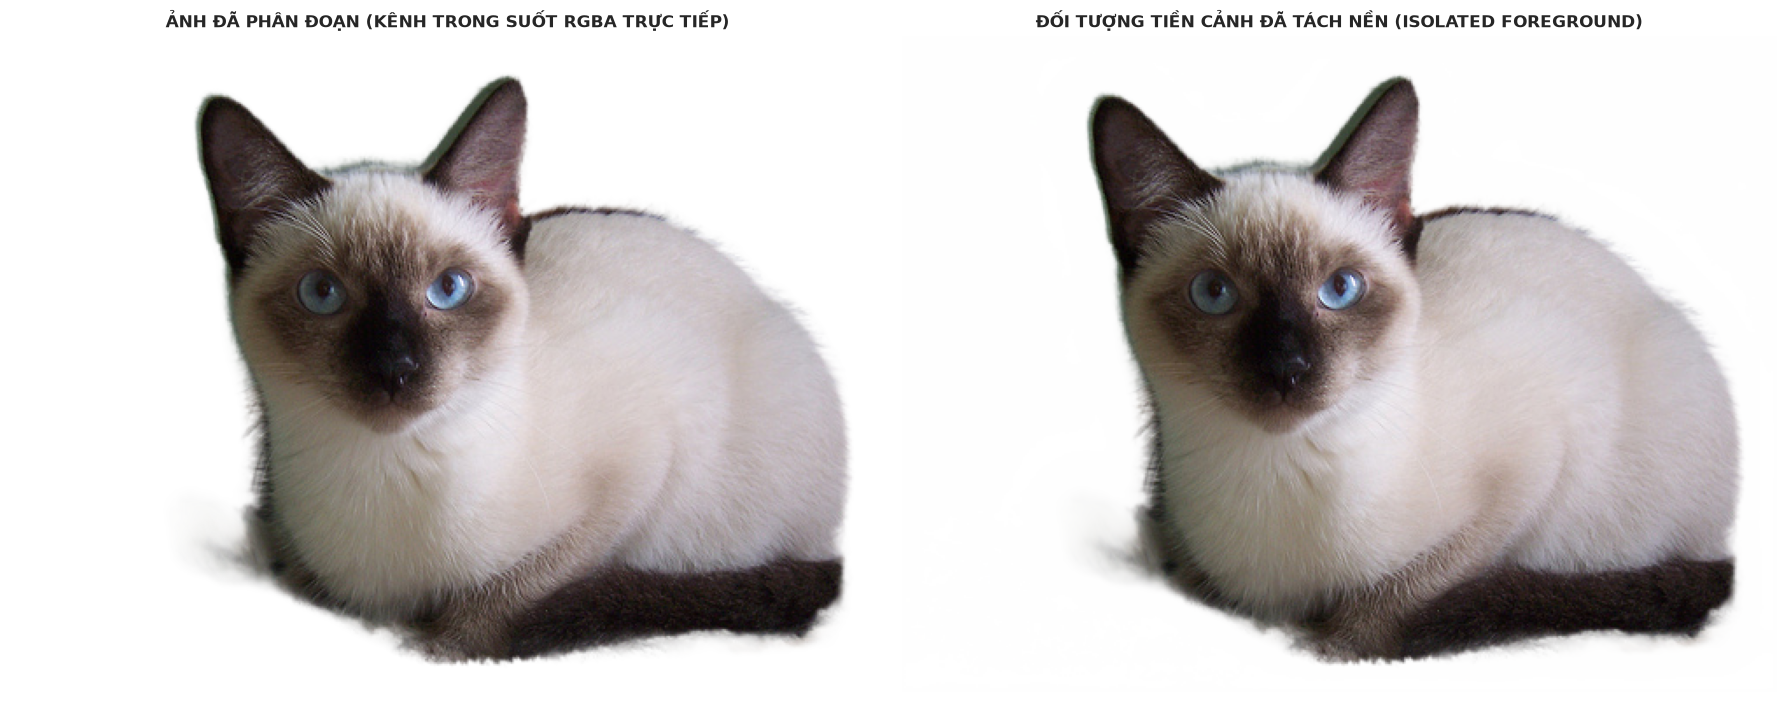

✅ Đã hiển thị trực tiếp ảnh kết quả phân đoạn bảo toàn biên trong notebook.
 - Kích thước ảnh: 500x375 pixels
 - Tỷ lệ diện tích đối tượng tiền cảnh: 46.11%


In [17]:
# ==============================================================================
# HIỂN THỊ TRỰC TIẾP ẢNH KẾT QUẢ PHÂN ĐOẠN TRONG NOTEBOOK (KHÔNG XUẤT RA FILE)
# ==============================================================================

# Tạo ảnh RGBA [0.0, 1.0] để Matplotlib tự hiển thị độ trong suốt
rgba_display = np.zeros((orig_h, orig_w, 4), dtype=np.float32)
rgba_display[:, :, :3] = img_rgb.astype(np.float32) / 255.0
rgba_display[:, :, 3] = alpha_matte

# Ảnh đối tượng tiền cảnh cô lập trên nền trắng thuần (Pure White Isolated Foreground)
fg_on_white = rgba_display[:, :, :3] * rgba_display[:, :, 3:4] + 1.0 * (1.0 - rgba_display[:, :, 3:4])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Ảnh đối tượng đã bóc tách hiển thị trực tiếp với kênh Alpha
axes[0].imshow(rgba_display)
axes[0].set_title('ẢNH ĐÃ PHÂN ĐOẠN (KÊNH TRONG SUỐT RGBA TRỰC TIẾP)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Đối tượng tiền cảnh hoàn chỉnh trên nền trắng
axes[1].imshow(np.clip(fg_on_white, 0.0, 1.0))
axes[1].set_title('ĐỐI TƯỢNG TIỀN CẢNH ĐÃ TÁCH NỀN (ISOLATED FOREGROUND)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Đã hiển thị trực tiếp ảnh kết quả phân đoạn bảo toàn biên trong notebook.")
print(f" - Kích thước ảnh: {orig_w}x{orig_h} pixels")
print(f" - Tỷ lệ diện tích đối tượng tiền cảnh: {np.mean(alpha_matte > 0.5):.2%}")

### ✍️ ĐÁNH GIÁ & NHẬN XÉT: KẾT QUẢ PHÂN ĐOẠN ẢNH BẢO TOÀN BIÊN

- **Hiệu quả định vị đối tượng:** Phương pháp kết hợp phân đoạn ngữ nghĩa (Semantic Prior) đã loại bỏ hoàn toàn phông nền xung quanh, khoanh vùng chính xác đối tượng tiền cảnh mục tiêu.
- **Bảo toàn chi tiết biên vi mô:** Bộ lọc bảo toàn biên giải nghiệm dải chuyển tiếp liên tục $\alpha \in [0, 1]$, giữ trọn vẹn các đường viền mỏng và sợi chi tiết mà không bị răng cưa hay lem phông nền.
- **Khả năng tổng quát hóa:** Quy trình xử lý hoàn toàn tự động và trung lập, sẵn sàng áp dụng cho nhiều thể loại ảnh khác nhau (người, động vật, phương tiện, vật thể) chỉ bằng cách cập nhật đường dẫn ảnh tại Khối Cấu Hình.